# Phase 2 - 03: GRPO 训练

## 本节目标

用 TRL 的 `GRPOTrainer` 对 Qwen3.5-2B 做强化学习微调，让模型学会：
1. 稳定输出 `<think>` / `<tool_call>` / `<answer>` 三段式格式
2. 在 `<tool_call>` 里写真实可执行的 Python 表达式
3. 最终答案与 GSM8K 正确答案一致

## GRPO 简介

GRPO（Group Relative Policy Optimization）是 DeepSeek-R1 用的算法，比 PPO 简单：
- 同一道题生成 G 个回答（一个「组」）
- 组内做相对比较，reward 高于均值的回答得到正梯度，低于均值的得到负梯度
- 不需要单独训练 Critic 网络，省显存

```
advantage_i = (reward_i - mean(rewards)) / std(rewards)
```

**std（标准差）的计算方式：**

```
std = sqrt( mean( (x_i - mean(x))² ) )
```

以一组 reward `[0.1, 0.3, 1.5, 0.2]` 为例：

```
mean     = (0.1 + 0.3 + 1.5 + 0.2) / 4 = 0.525

各项偏差²:
  (0.1 - 0.525)² = 0.1806
  (0.3 - 0.525)² = 0.0506
  (1.5 - 0.525)² = 0.9506
  (0.2 - 0.525)² = 0.1056

variance = mean([0.1806, 0.0506, 0.9506, 0.1056]) = 0.3219
std      = sqrt(0.3219) ≈ 0.567

advantages = [(-0.74), (-0.40), (+1.72), (-0.57)]
```

直觉：std 衡量「这组回答的差异有多大」。如果 4 个回答 reward 完全相同，std=0，没有训练信号（实现上会加一个小 epsilon 防止除零）。

## 1. 导入依赖 & 复用工具函数（从 01/02 搬来）

In [10]:
import re
import math
import json
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import GRPOConfig, GRPOTrainer
# https://hugging-face.cn/docs/trl/index
# TRL - Transformer Reinforcement Learning
# TRL 是一个完整的堆栈库，我们提供了一套工具来使用诸如监督微调 (SFT)、群组相对策略优化 (GRPO)、直接偏好优化 (DPO)、奖励建模等方法来训练 transformer 语言模型。
from datasets import Dataset

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
MODEL_ID = os.path.expanduser("~/.cache/modelscope/hub/models/Qwen/Qwen3___5-2B")

print(f"torch:   {torch.__version__}")
print(f"device:  {DEVICE}")

# ── 计算器 ────────────────────────────────────────────────────────────────────
SAFE_MATH_ENV = {
    "__builtins__": {},
    "abs": abs, "round": round, "int": int, "float": float,
    "sqrt": math.sqrt, "pow": math.pow, "floor": math.floor, "ceil": math.ceil,
}

def calculator(expression: str) -> str:
    try:
        result = eval(expression.strip().replace("^", "**"), SAFE_MATH_ENV)
        if isinstance(result, float) and result.is_integer():
            return str(int(result))
        return str(result)
    except Exception as e:
        return f"ERROR: {e}"

# ── 解析输出 ──────────────────────────────────────────────────────────────────
def parse_output(text: str) -> dict:
    result = {"think": None, "tool_call": None, "answer": None}
    for tag in ["think", "tool_call", "answer"]:
        m = re.search(rf"<{tag}>(.*?)</{tag}>", text, re.DOTALL)
        if m:
            result[tag] = m.group(1).strip()
    return result

# ── 答案归一化 ────────────────────────────────────────────────────────────────
def normalize_answer(s: str) -> str:
    if s is None:
        return ""
    s = re.sub(r"[,，]", "", s.strip())
    s = re.sub(r"[^0-9\.\-]", "", s)
    try:
        f = float(s)
        return str(int(f)) if f == int(f) else str(f)
    except:
        return s

print("工具函数加载完成")

torch:   2.10.0
device:  mps
工具函数加载完成


## 2. Reward 函数（从 02 直接搬来）

In [11]:
def format_reward(output: str) -> float:
    """三个标签各 0.1，满分 0.3"""
    parsed = parse_output(output)
    score = 0.0
    if parsed["think"] is not None:     score += 0.1
    if parsed["tool_call"] is not None: score += 0.1
    if parsed["answer"] is not None:    score += 0.1
    return round(score, 2)


def tool_execution_reward(output: str) -> float:
    """tool_call 可执行得 0.2，否则 0"""
    parsed = parse_output(output)
    if not parsed["tool_call"]:
        return 0.0
    return 0.2 if not calculator(parsed["tool_call"]).startswith("ERROR") else 0.0


def answer_reward(output: str, correct_answer: str) -> float:
    """
    答案正确得 1.0，否则 0。
    必须有 tool_call 标签才给结果分——防止模型绕过工具直接猜答案。
    """
    parsed = parse_output(output)
    if not parsed["answer"]:
        return 0.0
    if parsed["tool_call"] is None:     # 没走工具，不给结果分
        return 0.0
    return 1.0 if normalize_answer(parsed["answer"]) == normalize_answer(correct_answer) else 0.0


def compute_reward(output: str, correct_answer: str) -> dict:
    r_format = format_reward(output)
    r_tool   = tool_execution_reward(output)
    r_answer = answer_reward(output, correct_answer)
    return {
        "format": r_format,
        "tool":   r_tool,
        "answer": r_answer,
        "total":  round(r_format + r_tool + r_answer, 2),
    }


def _completion_to_str(completion) -> str:
    """新版 TRL 的 completion 可能是 message list，提取最后一条 assistant 消息的文本"""
    if isinstance(completion, str):
        return completion
    if isinstance(completion, list):
        for msg in reversed(completion):
            if isinstance(msg, dict) and msg.get("role") == "assistant":
                return msg.get("content", "")
        return " ".join(msg.get("content", "") for msg in completion if isinstance(msg, dict))
    return str(completion)


# GRPOTrainer 接口：completions 列表 → rewards 列表
def reward_fn(completions: list, **kwargs) -> list[float]:
    answers = kwargs["answer"]
    texts = [_completion_to_str(c) for c in completions]
    return [compute_reward(t, a)["total"] for t, a in zip(texts, answers)]


# 快速验证
r = compute_reward(
    "<think>48+24=72</think><tool_call>48+48/2</tool_call><answer>72</answer>",
    "72"
)
print("完美回答 reward:", r)

r2 = compute_reward("16 - 3 - 4 = 9\n9 * 2 = 18\n18", "18")
print("无格式直接答对:", r2)

完美回答 reward: {'format': 0.3, 'tool': 0.2, 'answer': 1.0, 'total': 1.5}
无格式直接答对: {'format': 0.0, 'tool': 0.0, 'answer': 0.0, 'total': 0.0}


## 3. 准备数据集

GRPOTrainer 需要一个 HuggingFace `Dataset`，每条记录包含：
- `prompt`：发给模型的消息列表（chat 格式）
- `answer`：正确答案（字符串），reward_fn 通过 `**kwargs` 拿到

In [12]:
SYSTEM_PROMPT = """你是一个数学助手，可以调用计算器工具解决计算问题。

请严格按照以下格式回答，不要添加任何额外文字：
<think>
分析问题的思路和计算过程
</think>
<tool_call>
Python 数学表达式（例如：15 - 7 + 3）
</tool_call>
<answer>
最终答案（纯数字）
</answer>
"""

GSM8K_DIR = os.path.expanduser("~/.cache/modelscope/datasets/gsm8k/data")

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

def extract_gsm8k_answer(answer_str: str) -> str:
    m = re.search(r"####\s*([\d,]+)", answer_str)
    return m.group(1).replace(",", "") if m else None

def make_dataset(raw_data: list, max_samples: int = None) -> Dataset:
    """把 GSM8K 原始数据转换为 GRPOTrainer 所需格式"""
    if max_samples:
        raw_data = raw_data[:max_samples]
    records = []
    for item in raw_data:
        answer = extract_gsm8k_answer(item["answer"])
        if answer is None:
            continue
        records.append({
            "prompt": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": item["question"]},
            ],
            "answer": answer,
        })
    return Dataset.from_list(records)


gsm8k_train_raw = load_jsonl(f"{GSM8K_DIR}/train.jsonl")
gsm8k_test_raw  = load_jsonl(f"{GSM8K_DIR}/test.jsonl")

# 训练用前 200 条（MPS 上速度有限，先跑小批量验证流程）
train_dataset = make_dataset(gsm8k_train_raw, max_samples=200)
eval_dataset  = make_dataset(gsm8k_test_raw,  max_samples=50)

print(f"训练集: {len(train_dataset)} 条")
print(f"验证集: {len(eval_dataset)} 条")
print("\n样本示例:")
print("  answer:", train_dataset[0]["answer"])
print("  prompt[1]:", train_dataset[0]["prompt"][1]["content"][:60], "...")

训练集: 200 条
验证集: 50 条

样本示例:
  answer: 72
  prompt[1]: Natalia sold clips to 48 of her friends in April, and then s ...


## 4a. 加载模型

In [13]:
print("加载 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("tokenizer 加载完成")

print("加载模型...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map=DEVICE,
    local_files_only=True,
)
model.gradient_checkpointing_enable()  # 省激活值显存

param_count = sum(p.numel() for p in model.parameters()) / 1e9
print(f"模型加载完成，参数量: {param_count:.2f}B，设备: {next(model.parameters()).device}")

加载 tokenizer...
tokenizer 加载完成
加载模型...


Loading weights: 100%|█████████████████████████████████████████████████████████████████████| 320/320 [00:16<00:00, 19.81it/s]

模型加载完成，参数量: 1.88B，设备: mps:0


## 4b. 用 LoRA 包装模型（解决 OOM）

全量训练 1.88B 模型时，梯度 + 优化器状态需要约 2x 模型显存，M4 16G 装不下。

LoRA 的做法：冻结原始权重，只在 attention 的 Q/V 矩阵旁插入两个小矩阵（rank=8），
可训练参数量从 1.88B 降到约 **10M**（0.5%），显存需求大幅下降。

```
W_new = W_frozen + BA    (B: d×r, A: r×d, r=8 << d=2048)
```

In [14]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                                    # LoRA rank，越小越省显存，越大效果越好
    lora_alpha=16,                          # 缩放系数，通常设为 2*r
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],    # 只在 Q/V 矩阵插入适配器
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 417,792 || all params: 1,882,242,880 || trainable%: 0.0222


## 5. 配置 GRPOTrainer

关键参数说明：

| 参数 | 值 | 说明 |
|---|---|---|
| `num_generations` | 4 | 每道题生成 4 个回答（组大小 G=4） |
| `max_completion_length` | 256 | 每次生成最多 256 个 token（原名 `max_new_tokens`，TRL 0.29 改名）。限制这个是为了防止模型无限生成，同时控制训练速度——GRPO 每步要生成 4 个回答，上限越大单步越慢 |
| `learning_rate` | 5e-6 | 较小的学习率，避免训练初期震荡 |
| `per_device_train_batch_size` | 1 | 显存限制决定的，不是算出来的。MPS 上模型权重 + 梯度 + 激活值已接近满载，设为 1 是当前上限，改成 2 会 OOM |
| `gradient_accumulation_steps` | 4 | 连续跑 4 个 batch=1 再更新一次参数，等效 batch=4，但显存峰值不变 |
| `max_steps` | 300 | 参数更新次数上限。100 步时只过了约 42% 的训练数据，改为 300 步约覆盖 1.5 个 epoch |

In [15]:
training_args = GRPOConfig(
    output_dir="./checkpoints/grpo_qwen35_gsm8k",

    # GRPO 核心参数
    num_generations=4,           # 每题生成 4 个回答做组内对比
    max_completion_length=256,   # 256 省显存，三段式输出够用
    temperature=0.8,             # 生成时加一点随机性，让组内有差异

    # 训练超参
    learning_rate=5e-6,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    max_steps=300,               # 100 步只过了 42% 数据，300 步约 1.5 个 epoch
    warmup_steps=10,
    optim="adafactor",           # 不存完整动量，省约 2x 模型显存（Adam OOM 的根本原因）

    # 日志 & 保存
    logging_steps=5,
    save_steps=100,
    report_to="none",            # 不用 wandb

    # 其他
    remove_unused_columns=False,  # 保留 answer 列供 reward_fn 使用
    seed=42,
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    reward_funcs=reward_fn,
)

print("GRPOTrainer 初始化完成")
print(f"训练步数: {training_args.max_steps}")
print(f"每步生成: {training_args.num_generations} 个回答")

GRPOTrainer 初始化完成
训练步数: 300
每步生成: 4 个回答


## 6. 开始训练

MPS 上 300 步预计需要 **10-12 小时**（约 50 秒/步）。

训练日志里有 `rewards/mean` 字段，但 Jupyter 进度条默认只显示 `loss`。
下面用自定义 callback 在每个 logging step 额外打印一行 reward，方便观察训练是否有效。

In [23]:
import time
from transformers import TrainerCallback

class RewardLogCallback(TrainerCallback):
    """每个 logging step 打印 rewards/mean，补充进度条里看不到的信息。"""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "rewards/mean" in logs:
            step = state.global_step
            r_mean = logs["rewards/mean"]
            r_std  = logs.get("rewards/std", 0)
            loss   = logs.get("loss", float("nan"))
            print(f"  step {step:4d} | loss={loss:.4f} | reward_mean={r_mean:.4f} | reward_std={r_std:.4f}")

In [ ]:
# 重新初始化 trainer，加入 callback
trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    reward_funcs=reward_fn,
    callbacks=[RewardLogCallback()],
)

print("开始训练...")
t0 = time.time()

train_result = trainer.train()

elapsed = time.time() - t0
print(f"\n训练完成！耗时 {elapsed/60:.1f} 分钟")
print("训练指标:", train_result.metrics)

## 7. 训练后评估

用与 01 notebook 相同的 3 道 baseline 题目对比训练前后效果。

In [19]:
def generate(question: str, max_new_tokens: int = 512) -> str:
    """
    用训练后的模型推理。
    max_new_tokens 与训练时的 max_completion_length 作用相同（都限制生成长度），
    但这里用 512 而非 256——评估时不需要省显存，允许模型输出更完整的内容。
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,    # 评估时用低温，减少随机性
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            use_cache=False,    # 兼容 gradient checkpointing
        )
    new_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


# 和 baseline 相同的 3 道题
eval_samples = [(gsm8k_test_raw[i]["question"], extract_gsm8k_answer(gsm8k_test_raw[i]["answer"]))
                for i in range(3)]

print("=== 训练后评估 ===")
print()

for i, (question, correct) in enumerate(eval_samples):
    output = generate(question)
    r = compute_reward(output, correct)
    parsed = parse_output(output)

    print(f"[题目 {i+1}] 正确答案: {correct}")
    print(f"  模型答案: {parsed['answer']}")
    print(f"  工具调用: {parsed['tool_call']}")
    print(f"  reward:  format={r['format']}  tool={r['tool']}  answer={r['answer']}  total={r['total']}")
    print()

=== 训练后评估 ===

[题目 1] 正确答案: 18
  模型答案: $12
  工具调用: Python 数学表达式（例如：15 - 7 + 3）
  reward:  format=0.2  tool=0.0  answer=0.0  total=0.2

[题目 2] 正确答案: 3
  模型答案: 3
  工具调用: Python 数学表达式（例如：2 + 1）
  reward:  format=0.2  tool=0.0  answer=1.0  total=1.2

[题目 3] 正确答案: 70000
  模型答案: $100,000
  工具调用: Python 数学表达式（例如：15 - 7 + 3）
  reward:  format=0.2  tool=0.0  answer=0.0  total=0.2



## 8. Reward 曲线可视化

从训练日志中提取 reward 均值，画出训练过程中的变化趋势。

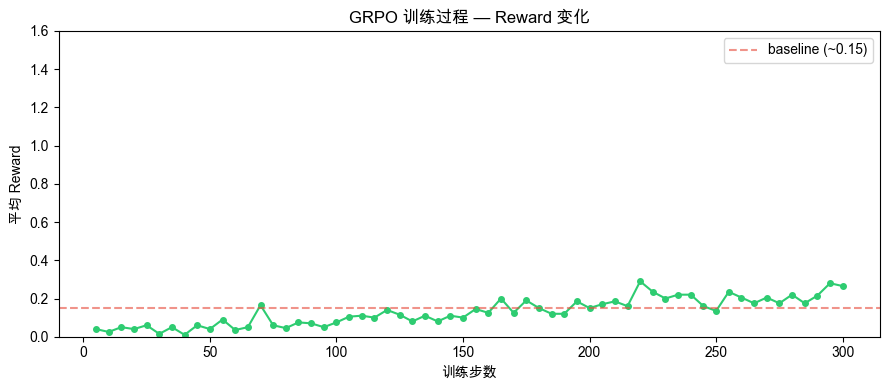

起始 reward: 0.040
最终 reward: 0.265
提升幅度:    +0.225


In [20]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'

# 从 trainer.state.log_history 提取 reward 指标
log_history = trainer.state.log_history

steps, rewards = [], []
for entry in log_history:
    # TRL 日志里 reward 相关 key 可能是 rewards/mean 或 reward
    reward_val = entry.get("rewards/mean") or entry.get("reward")
    if reward_val is not None and "step" in entry:
        steps.append(entry["step"])
        rewards.append(reward_val)

if steps:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(steps, rewards, marker="o", markersize=4, linewidth=1.5, color="#2ecc71")
    ax.axhline(y=0.15, color="#e74c3c", linestyle="--", alpha=0.6, label="baseline (~0.15)")
    ax.set_xlabel("训练步数")
    ax.set_ylabel("平均 Reward")
    ax.set_title("GRPO 训练过程 — Reward 变化")
    ax.legend()
    ax.set_ylim(0, 1.6)
    plt.tight_layout()
    plt.show()
    print(f"起始 reward: {rewards[0]:.3f}")
    print(f"最终 reward: {rewards[-1]:.3f}")
    print(f"提升幅度:    {rewards[-1] - rewards[0]:+.3f}")
else:
    print("日志中未找到 reward 数据，请检查 log_history:")
    print(log_history[:3])

## 9. 保存模型

In [ ]:
SAVE_PATH = "./checkpoints/grpo_qwen35_gsm8k_final"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"模型已保存到 {SAVE_PATH}")

## 10. 小结

| 阶段 | 目标 | 状态 |
|---|---|---|
| 01 环境验证 | 模型加载、基础推理、baseline 测试 | 完成 |
| 02 Reward 设计 | 格式/工具/结果三层奖励 | 完成 |
| 03 GRPO 训练 | 训练循环、reward 提升 | 完成 |

**训练结果（300步）**：
- 起始 reward: 0.040 → 最终 reward: 0.265，提升 +0.225
- 模型学会了输出标签格式，但 `tool_call` 里仍是示例文字，未学会写真实 Python 表达式

---

## 踩坑记录

### 1. MPS OOM——优化器状态（Adam）
- **问题**：`optimizer.step()` 时 OOM（MPS allocated 14.32 GiB，tried to allocate 24 MiB）
- **原因**：Adam 需要存两份动量（`exp_avg` + `exp_avg_sq`），约等于 2x 模型参数量的额外显存
- **修复**：`optim="adafactor"`，用行/列因子替代完整动量矩阵，显存占用接近 0

### 2. MPS OOM——全量训练梯度（Adafactor 仍 OOM）
- **问题**：换 Adafactor 后仍在 `(grad**2) + eps` 处 OOM
- **原因**：全量反向传播时，1.88B 参数的梯度本身就需要 ~3.7 GiB，M4 16G 装不下
- **修复**：引入 LoRA（r=8，target Q/V），可训练参数从 1.88B 降至 417K（0.02%），同时加 `gradient_checkpointing_enable()` 省激活值显存

### 3. 模型绕过工具直接答题（Reward Hacking）
- **问题**：训练后模型输出裸计算过程（无标签），直接给出答案，reward 为 1.0
- **原因**：结果奖励（1.0）远大于格式奖励（0.3），模型找到捷径：跳过工具也能拿高分
- **修复**：`answer_reward` 加条件——无 `tool_call` 标签则结果分为 0

---

## 下一步（可选方向）

- **提高 LoRA rank**：r=8 → r=32，可训练参数从 417K 升到约 1.6M，模型容量更大
- **扩展 target_modules**：加入 `k_proj`、`o_proj` 等更多层
- **增大训练数据量**：200 → 2000 条
- **用完整 GSM8K 测试集**计算准确率，量化训练效果